In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Dataset


In [9]:
try:
    df = pd.read_csv('/content/cleaned_merged_heart_dataset.csv')
    print('Dataset loaded successfully.')
    display(df.head())
    print(f"Dataset shape: {df.shape}")
    print("\nColumn information:")
    df.info()
except FileNotFoundError:
    print("Error: The file '/content/cleaned_merged_heart_dataset.csv' was not found. Please ensure it's uploaded or the path is correct.")
    df = None

Dataset loaded successfully.


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Dataset shape: (1888, 14)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1888 non-null   int64  
 1   sex       1888 non-null   int64  
 2   cp        1888 non-null   int64  
 3   trestbps  1888 non-null   int64  
 4   chol      1888 non-null   int64  
 5   fbs       1888 non-null   int64  
 6   restecg   1888 non-null   int64  
 7   thalachh  1888 non-null   int64  
 8   exang     1888 non-null   int64  
 9   oldpeak   1888 non-null   float64
 10  slope     1888 non-null   int64  
 11  ca        1888 non-null   int64  
 12  thal      1888 non-null   int64  
 13  target    1888 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 206.6 KB


### Data Preprocessing for KNN


In [3]:
if df is not None:
    # Define features (X) and target (y)
    # Assuming 'target' is the column containing the target variable (0 or 1)
    if 'target' in df.columns:
        X = df.drop('target', axis=1)
        y = df['target']

        # Split data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

        print(f"X_train shape: {X_train.shape}")
        print(f"X_test shape: {X_test.shape}")
        print(f"y_train value counts:\n{y_train.value_counts()}")
        print(f"y_test value counts:\n{y_test.value_counts()}")

        # Scale the features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        print("\nFeatures scaled successfully.")

    else:
        print("Error: The 'target' column was not found in the dataset. Please verify the column name.")
        X, y = None, None
else:
    print("Skipping preprocessing as dataset was not loaded.")

X_train shape: (1321, 13)
X_test shape: (567, 13)
y_train value counts:
target
1    684
0    637
Name: count, dtype: int64
y_test value counts:
target
1    293
0    274
Name: count, dtype: int64

Features scaled successfully.


### Apply K-Nearest Neighbors (KNN) Classifier


Accuracy: 0.8660

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.86       274
           1       0.85      0.90      0.87       293

    accuracy                           0.87       567
   macro avg       0.87      0.86      0.87       567
weighted avg       0.87      0.87      0.87       567


Confusion Matrix:
[[228  46]
 [ 30 263]]


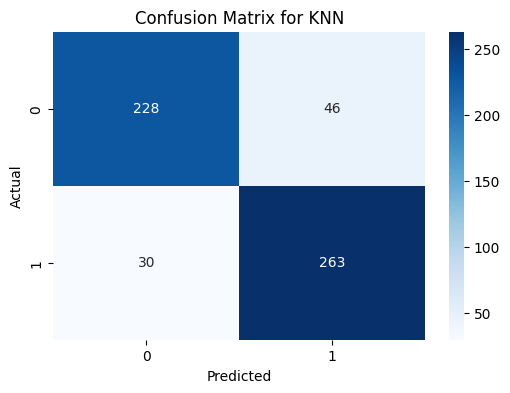

In [4]:
if 'target' in df.columns and X is not None:
    # Initialize and train the KNN model
    # Choosing k=5
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)

    # Make predictions on the scaled test set
    y_pred = knn.predict(X_test_scaled)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    # Visualize the confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix for KNN')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
else:
    print("Skipping KNN application as prerequisites (dataset, target column) are not met.")

### Compare Synthetic Data with Synthetic Target and Predicted Target


In [8]:
# Create a synthetic target for the 15 synthetic data points
# This is a hypothetical target for comparison purposes
synthetic_target = np.array([1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1]) # Example synthetic target values

# Combine synthetic data, synthetic target, and predicted target into a single DataFrame
if 'synthetic_results' in locals() and 'synthetic_target' in locals():
    synthetic_comparison = synthetic_results.copy()
    synthetic_comparison['synthetic_target'] = synthetic_target

    print("\nSynthetic Data with Synthetic Target and Predicted Target:")
    display(synthetic_comparison)
else:
    print("Error: Synthetic results or synthetic target not available for comparison.")


Synthetic Data with Synthetic Target and Predicted Target:


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,predicted_target,synthetic_target
0,45,1,2,130,210,0,1,160,0,1.0,2,0,2,1,1
1,60,0,1,145,250,1,0,120,1,2.5,1,2,3,0,0
2,52,1,3,120,200,0,1,175,0,0.5,2,0,2,1,1
3,38,0,0,115,180,0,0,190,0,0.0,2,0,2,1,1
4,70,1,2,160,280,1,1,100,1,3.0,1,3,3,0,0
5,55,0,1,135,220,0,0,140,0,1.5,2,1,2,1,1
6,48,1,0,125,190,0,1,180,0,0.2,2,0,2,1,1
7,63,0,3,150,260,1,0,110,1,2.8,1,2,3,0,0
8,40,1,1,110,170,0,1,195,0,0.8,2,0,2,1,1
9,58,0,2,140,230,0,0,130,1,2.0,1,1,3,0,0
